Understanding Customer Churn in the Telecommunications Industry

Customer churn represents the loss of clients over a given period. In the telecommunications industry, high churn rates directly impact profitability due to the high cost of customer acquisition. This project leverages data visualization techniques to identify patterns and key drivers associated with customer churn.

In [59]:
import pandas as pd
import matplotlib.pyplot as plt


import seaborn as sns
from plotnine import *


In [39]:
telco=pd.read_csv("C:/Users/Khaled/Documents/telco_customer_churn2.csv")
telco.head(3)

,customer_id,gender,senior_citizen,partner,DEPENDENTS,tenure,pho_ne_service,multi$ple_l@ines,int#e&rnet_service,onli!ne_secur^ity,...,device_protectio+n,TECH_SUP(PORT,st-rea(min(g_tv,streaming_movies,c!ontract,paperless_b%illing,paym#ent_*metho_d,mon^thly_char^ges,t-otal_c(harges,ch_u+rn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


In [40]:
print(telco.columns)
print(telco.shape)
print(telco.size)
print(telco.isna().sum())

Index(['customer_id', 'gender', 'senior_citizen', 'partner', 'DEPENDENTS ',
       'tenure', 'pho_ne_service', 'multi$ple_l@ines', 'int#e&rnet_service',
       'onli!ne_secur^ity', '&onl!ine_ba^c@kup', 'device_protectio+n',
       'TECH_SUP(PORT', 'st-rea(min(g_tv', 'streaming_movies', 'c!ontract',
       'paperless_b%illing', 'paym#ent_*metho_d', 'mon^thly_char^ges',
       't-otal_c(harges ', 'ch_u+rn '],
      dtype='object')
(7748, 21)
162708
customer_id            0
gender                 0
senior_citizen         0
partner                0
DEPENDENTS             0
tenure                 0
pho_ne_service         0
multi$ple_l@ines       0
int#e&rnet_service     0
onli!ne_secur^ity      0
&onl!ine_ba^c@kup      0
device_protectio+n     0
TECH_SUP(PORT          0
st-rea(min(g_tv        0
streaming_movies       0
c!ontract              0
paperless_b%illing     0
paym#ent_*metho_d      0
mon^thly_char^ges      0
t-otal_c(harges       11
ch_u+rn                0
dtype: int64


In [41]:
telco['t-otal_c(harges '] = pd.to_numeric(telco['t-otal_c(harges '], errors='coerce')
telco.head()
telco.tail()
telco.isna().sum()

customer_id            0
gender                 0
senior_citizen         0
partner                0
DEPENDENTS             0
tenure                 0
pho_ne_service         0
multi$ple_l@ines       0
int#e&rnet_service     0
onli!ne_secur^ity      0
&onl!ine_ba^c@kup      0
device_protectio+n     0
TECH_SUP(PORT          0
st-rea(min(g_tv        0
streaming_movies       0
c!ontract              0
paperless_b%illing     0
paym#ent_*metho_d      0
mon^thly_char^ges      0
t-otal_c(harges       11
ch_u+rn                0
dtype: int64

In [42]:
telco.columns = telco.columns.str.lower().str.replace('_', '')
telco.columns = telco.columns.str.strip().str.replace('[^a-zA-Z0-0_]', '', regex=True)
telco.columns

Index(['customerid', 'gender', 'seniorcitizen', 'partner', 'dependents',
       'tenure', 'phoneservice', 'multiplelines', 'internetservice',
       'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport',
       'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling',
       'paymentmethod', 'monthlycharges', 'totalcharges', 'churn'],
      dtype='object')

In [53]:
telco['totalcharges'] = telco['totalcharges'].fillna(telco['totalcharges'].median())


In [54]:
telco['churn'] = telco['churn'].replace({'Yes': 1, 'No': 0}).infer_objects(copy=False)
telco.head(5)

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0


The totalcharges variable was converted to a numeric format to ensure analytical operations. Invalid entries were coerced into missing values (NaN), which were subsequently replaced using the median to preserve the distribution of the data and reduce the impact of outliers.

Also, the churn variable was encoded into binary format (1 = churn, 0 = no churn) to help analysis and visualization.

In [49]:
telco.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7748 entries, 0 to 7747
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerid        7748 non-null   object 
 1   gender            7748 non-null   object 
 2   seniorcitizen     7748 non-null   int64  
 3   partner           7748 non-null   object 
 4   dependents        7748 non-null   object 
 5   tenure            7748 non-null   int64  
 6   phoneservice      7748 non-null   object 
 7   multiplelines     7748 non-null   object 
 8   internetservice   7748 non-null   object 
 9   onlinesecurity    7748 non-null   object 
 10  onlinebackup      7748 non-null   object 
 11  deviceprotection  7748 non-null   object 
 12  techsupport       7748 non-null   object 
 13  streamingtv       7748 non-null   object 
 14  streamingmovies   7748 non-null   object 
 15  contract          7748 non-null   object 
 16  paperlessbilling  7748 non-null   object 


In [51]:
telco.isna().sum()

customerid          0
gender              0
seniorcitizen       0
partner             0
dependents          0
tenure              0
phoneservice        0
multiplelines       0
internetservice     0
onlinesecurity      0
onlinebackup        0
deviceprotection    0
techsupport         0
streamingtv         0
streamingmovies     0
contract            0
paperlessbilling    0
paymentmethod       0
monthlycharges      0
totalcharges        0
churn               0
dtype: int64

Churn Distribution

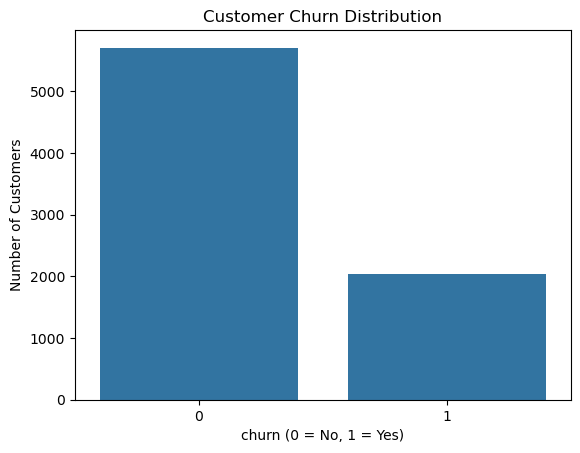

In [56]:
sns.countplot(x='churn', data=telco)
plt.title("Customer Churn Distribution")
plt.xlabel("churn (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")
plt.show()

The dataset shows that close to 2000 customers have churned, indicating a potential retention challenge.

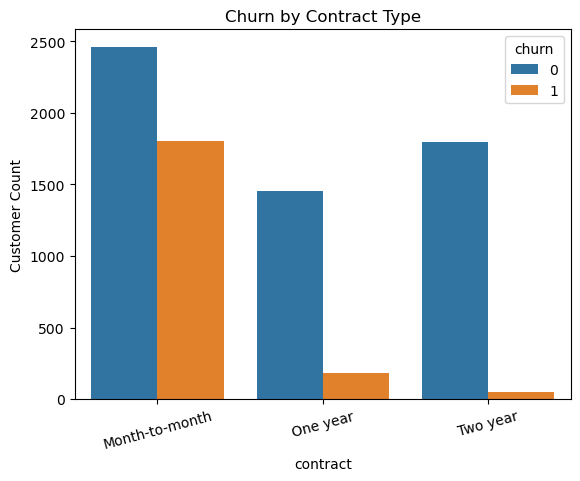

In [57]:
sns.countplot(x='contract', hue='churn', data=telco)
plt.title("Churn by Contract Type")
plt.xlabel("contract")
plt.ylabel("Customer Count")
plt.xticks(rotation=15)
plt.show()

his shows that customers on month-to-month contracts exhibit the highest churn rate, suggesting that lack of long-term commitment increases the likelihood of customer exit.

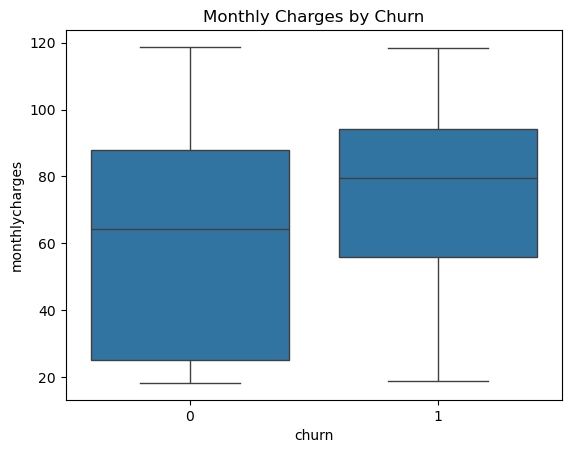

In [58]:
sns.boxplot(x='churn', y='monthlycharges', data=telco)
plt.title("Monthly Charges by Churn")
plt.xlabel("churn")
plt.ylabel("monthlycharges")
plt.show()

Customers who churn tend to have higher monthly charges, indicating price sensitivity as a key driver of churn.

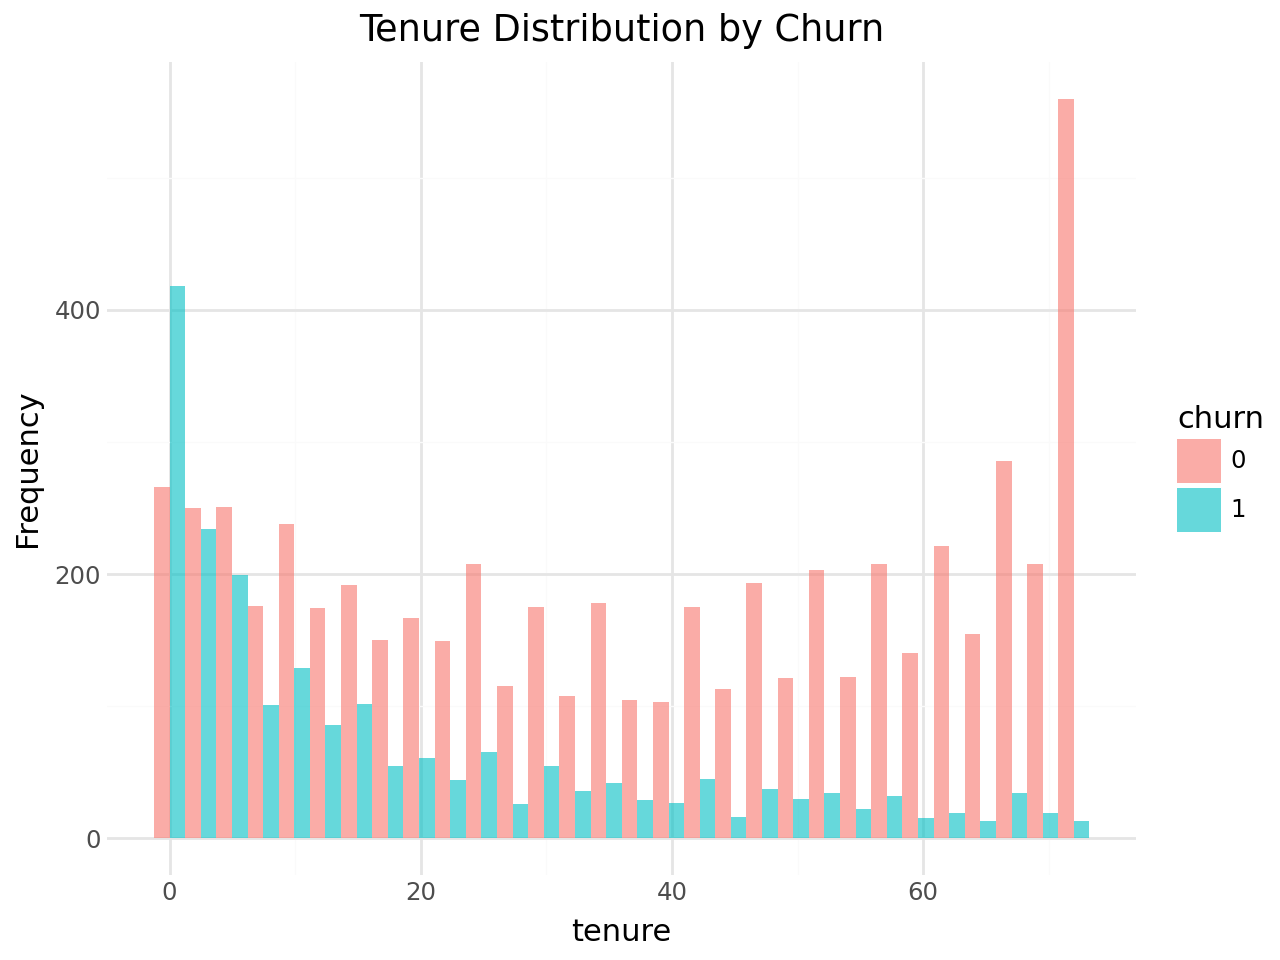

In [62]:
ggplot(telco, aes(x='tenure', fill='factor(churn)')) + \
    geom_histogram(bins=30, alpha=0.6, position='dodge') + \
    labs(
        title="Tenure Distribution by Churn",
        x="tenure",
        y="Frequency",
        fill="churn"
    ) + \
    theme_minimal()

    FINAL REFLECTION
This project showed the use of  data visualization to uncover business insights. By analyzing customer behavior patterns, it became evident that contract type, tenure, and pricing significantly influence churn. While the analysis provides valuable insights, further work could incorporate predictive modeling to identify customers that are at risk of churning.Churn is strongly associated with customer commitment level and cost structure. Customers with long-term contracts and lower monthly charges show significantly lower churn rates. Overall, this exercise highlights how data driven strategies can enhance customer retention and optimize business performance.